In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from collections import Counter

In [2]:
X_train = [[1,2],[2,3],[3,3],[6,5],[7,7]]
X_test = [[7,6]]
Y_train = [0,0,0,1,1]

In [3]:
df = pd.DataFrame(X_train)

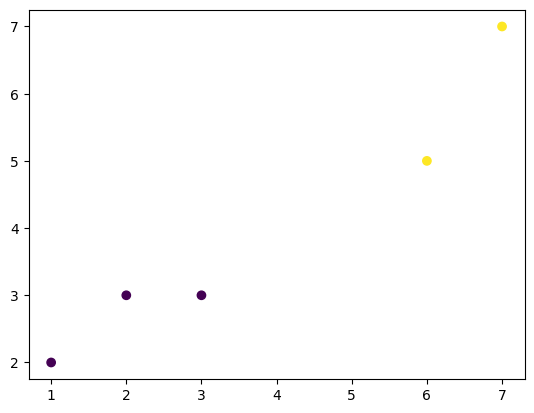

In [4]:
plt.scatter(df.iloc[:,0],df.iloc[:,1],c=Y_train)

In [5]:
class KNN:
    # Constructor of the class
    def __init__(self,k=3):
        self.k = k

    #Store the data
    def fit(self,x,y):
        self.X_train = np.array(x)
        self.Y_train = np.array(y)

    #Calculate Euclidian Distance
    def distance(self,x1,x2):
        d = np.sqrt(np.sum((x1-x2)**2))
        return(d)

    #Predict a single point
    def predict_single(self,x):
        dist = []
        for x_train in self.X_train:
            dist.append(self.distance(x,x_train))
        np.array(dist)

        #Get the index of K nearest neighbour
        k_index = np.argsort(dist)[:self.k]

        #Find the labels
        k_labels = self.Y_train[k_index]

        #Majority Count
        most_common = Counter((k_labels)).most_common(1)
        return(most_common[0][0])
        

In [12]:
knn = KNN(k=3)

In [15]:
knn.fit(X_train,Y_train)

In [16]:
knn.predict_single(X_test)

1

In [13]:
X_test = [[7,6]]

In [17]:
# Homework

In [19]:
from sklearn.datasets import load_iris

In [20]:
X = load_iris().data
Y = load_iris().target

In [21]:
df = pd.DataFrame(X,columns=load_iris().feature_names)

In [22]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [28]:
#Setosa, Versicolour,Verginica

In [29]:
df.size

600

In [30]:
#PCA

In [34]:
df = pd.read_csv("train.csv")

In [33]:
cd C:\Users\arnab\Documents\Python Programming\Datasets

C:\Users\arnab\Documents\Python Programming\Datasets


In [36]:
df.head() #-> MNIST dataset

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [37]:
df.shape

(42000, 785)

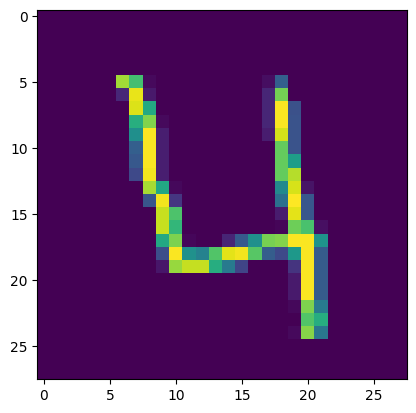

In [43]:
plt.imshow(df.iloc[3,1:].values.reshape(28,28))

In [57]:
X = df.iloc[:,1:]
X = X/255
Y = df.iloc[:,0]

In [58]:
from sklearn.model_selection import train_test_split

In [59]:
X_train,X_test,Y_train,Y_test = train_test_split(X,Y,test_size=0.2,random_state=42)

In [61]:
from sklearn.neighbors import KNeighborsClassifier

In [62]:
knn = KNeighborsClassifier(n_neighbors=5)

In [63]:
knn.fit(X_train,Y_train)

KNeighborsClassifier()

In [64]:
from sklearn.metrics import confusion_matrix
from mlxtend.plotting import plot_confusion_matrix

In [67]:
conf = confusion_matrix(Y_test,knn.predict(X_test))

(<Figure size 640x480 with 2 Axes>,
 <Axes: xlabel='predicted label', ylabel='true label'>)

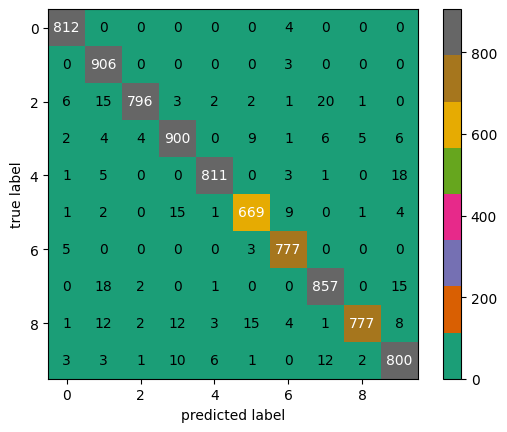

In [68]:
plot_confusion_matrix(conf,colorbar=True,cmap='Dark2')

In [69]:
from sklearn.metrics import accuracy_score

In [70]:
acc = accuracy_score(Y_test,knn.predict(X_test))
print(acc)

0.9648809523809524
